## NOAH x ARQ

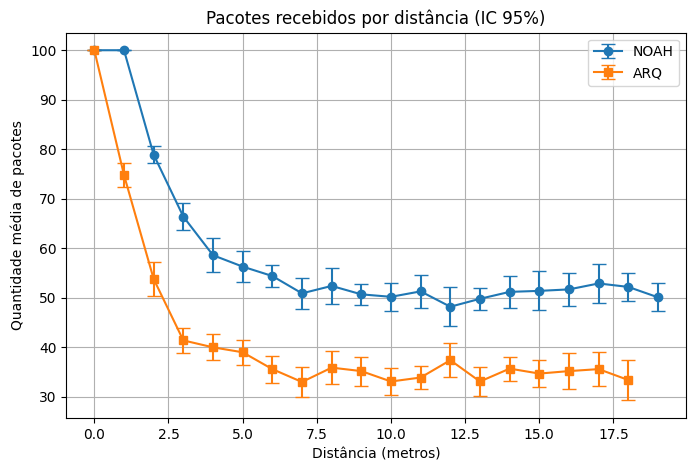

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


# ==================================================
# FUNÇÃO BASE (a sua, sem mudar a lógica)
# ==================================================
def contar_fim_do_pacote_por_distancia(caminho_arquivo):
    contagem = defaultdict(int)
    distancia_atual = None

    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        for linha in f:
            linha = linha.strip()

            m_dist = re.match(r'Distance between TX and RX is (\d+) meters', linha)
            if m_dist:
                distancia_atual = int(m_dist.group(1))
                continue

            if linha == "------FIM DO PACOTE-------":
                if distancia_atual is not None:
                    contagem[distancia_atual] += 1

    return contagem


# ==================================================
# MÉDIA + IC 95% PARA UM GRUPO DE ARQUIVOS
# ==================================================
def media_e_ic95_grupo(lista_arquivos):
    dados_por_distancia = defaultdict(list)

    for arquivo in lista_arquivos:
        contagem = contar_fim_do_pacote_por_distancia(arquivo)
        for dist, valor in contagem.items():
            dados_por_distancia[dist].append(valor)

    distancias = sorted(dados_por_distancia.keys())
    medias = []
    ic95 = []

    for d in distancias:
        valores = np.array(dados_por_distancia[d])
        n = len(valores)

        media = valores.mean()
        desvio = valores.std(ddof=1)
        erro_padrao = desvio / np.sqrt(n)

        intervalo = 1.96 * erro_padrao

        medias.append(media)
        ic95.append(intervalo)

    return distancias, medias, ic95


# ==================================================
# DEFINIÇÃO DOS ARQUIVOS
# ==================================================
grupo_A = [
    "resultsA1.txt", "resultsA2.txt", "resultsA3.txt", "resultsA4.txt", "resultsA5.txt",
    "resultsA6.txt", "resultsA7.txt", "resultsA8.txt", "resultsA9.txt", "resultsA10.txt"
]

grupo_B = [
    "resultsB1.txt", "resultsB2.txt", "resultsB3.txt", "resultsB4.txt", "resultsB5.txt",
    "resultsB6.txt", "resultsB7.txt", "resultsB8.txt", "resultsB9.txt", "resultsB10.txt"
]


# ==================================================
# CÁLCULO
# ==================================================
dist_A, media_A, ic95_A = media_e_ic95_grupo(grupo_A)
dist_B, media_B, ic95_B = media_e_ic95_grupo(grupo_B)


# ==================================================
# PLOT FINAL (COMPARAÇÃO)
# ==================================================
plt.figure(figsize=(8, 5))

plt.errorbar(
    dist_A, media_A, yerr=ic95_A,
    marker='o', capsize=5, label='NOAH'
)

plt.errorbar(
    dist_B, media_B, yerr=ic95_B,
    marker='s', capsize=5, label='ARQ'
)

plt.xlabel("Distância (metros)")
plt.ylabel("Quantidade média de pacotes")
plt.title("Pacotes recebidos por distância (IC 95%)")
plt.grid(True)
plt.legend()

plt.show()


## ARQ x Normal

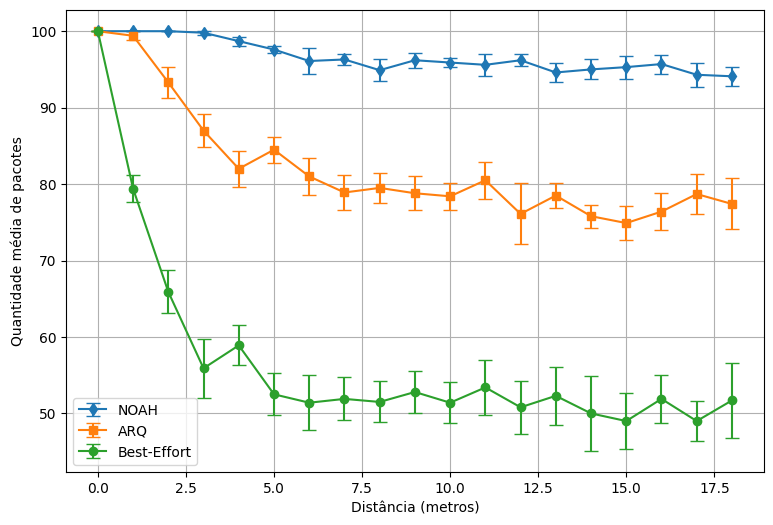

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


# ==================================================
# FUNÇÃO BASE
# ==================================================
def contar_fim_do_pacote_por_distancia(caminho_arquivo):
    contagem = defaultdict(int)
    distancia_atual = None

    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        for linha in f:
            linha = linha.strip()

            m_dist = re.match(r'Distance between TX and RX is (\d+) meters', linha)
            if m_dist:
                distancia_atual = int(m_dist.group(1))
                continue

            if linha == "------FIM DO PACOTE-------":
                if distancia_atual is not None:
                    contagem[distancia_atual] += 1

    return contagem


# ==================================================
# MÉDIA + IC 95% PARA UM GRUPO DE ARQUIVOS
# ==================================================
def media_e_ic95_grupo(lista_arquivos, dist_min=0, dist_max=18):
    dados_por_distancia = defaultdict(list)

    # Primeiro coleta todos os dados
    for arquivo in lista_arquivos:
        contagem = contar_fim_do_pacote_por_distancia(arquivo)

        for d in range(dist_min, dist_max + 1):
            valor = contagem.get(d, 0)
            dados_por_distancia[d].append(valor)

    distancias = list(range(dist_min, dist_max + 1))
    medias = []
    ic95 = []

    for d in distancias:
        valores = np.array(dados_por_distancia[d])
        n = len(valores)

        media = valores.mean()
        desvio = valores.std(ddof=1)
        erro_padrao = desvio / np.sqrt(n)
        intervalo = 1.96 * erro_padrao

        medias.append(media)
        ic95.append(intervalo)

    return distancias, medias, ic95


# ==================================================
# DEFINIÇÃO DOS ARQUIVOS
# ==================================================
grupo_A = [
    "resultsA1.txt", "resultsA2.txt", "resultsA3.txt", "resultsA4.txt", "resultsA5.txt",
    "resultsA6.txt", "resultsA7.txt", "resultsA8.txt", "resultsA9.txt", "resultsA10.txt"
]

grupo_B = [
    "resultsB1.txt", "resultsB2.txt", "resultsB3.txt", "resultsB4.txt", "resultsB5.txt",
    "resultsB6.txt", "resultsB7.txt", "resultsB8.txt", "resultsB9.txt", "resultsB10.txt"
]

grupo_C = [
    "resultsC1.txt", "resultsC2.txt", "resultsC3.txt", "resultsC4.txt", "resultsC5.txt",
    "resultsC6.txt", "resultsC7.txt", "resultsC8.txt", "resultsC9.txt", "resultsC10.txt"
]

#arquivo_D = "resultsD1.txt"  # Apenas um arquivo


# ==================================================
# CÁLCULO DOS GRUPOS COM MÉDIA
# ==================================================
dist_A, media_A, ic95_A = media_e_ic95_grupo(grupo_A)
dist_B, media_B, ic95_B = media_e_ic95_grupo(grupo_B)
dist_C, media_C, ic95_C = media_e_ic95_grupo(grupo_C)


"""# ==================================================
# PROCESSAMENTO DO GRUPO D (SEM MÉDIA)
# ==================================================
contagem_D = contar_fim_do_pacote_por_distancia(arquivo_D)

# Força eixo de 0 a 18 como no seu código que funciona
dist_D = list(range(0, 19))
valores_D = [contagem_D.get(d, 0) for d in dist_D]
valores_D[0] = 100"""


# ==================================================
# PLOT FINAL
# ==================================================
plt.figure(figsize=(9, 6))

plt.errorbar(dist_A, media_A, yerr=ic95_A,
             marker='d', capsize=5, label='NOAH')

plt.errorbar(dist_B, media_B, yerr=ic95_B,
             marker='s', capsize=5, label='ARQ')

plt.errorbar(dist_C, media_C, yerr=ic95_C,
             marker='o', capsize=5, label='Best-Effort')

"""plt.plot(dist_D, valores_D,
         marker='x', label='Grupo D (1 execução)')"""


plt.xlabel("Distância (metros)")
plt.ylabel("Quantidade média de pacotes")
plt.grid(True)
plt.legend()


plt.show()


In [ ]:
import pandas as pd
from google.colab import files

# Criar DataFrame incluindo Grupo D
tabela = pd.DataFrame({
    "Distância (m)": dist_A,
    "Média A": media_A,
    "IC95 A": ic95_A,
    "Média B": media_B,
    "IC95 B": ic95_B,
    "Média C": media_C,
    "IC95 C": ic95_C,
    #"Execução D": valores_D[:len(dist_A)]  # garante mesmo tamanho
})

print(tabela)

tabela.to_csv("Comparacao_Final.csv", index=False)

files.download("Comparacao_Final.csv")



    Distância (m)  Média A    IC95 A  Média B    IC95 B  Média C    IC95 C
0               0    100.0  0.000000    100.0  0.000000    100.0  0.000000
1               1    100.0  0.000000     99.4  0.598790     79.4  1.805849
2               2    100.0  0.000000     93.3  1.982735     65.9  2.824486
3               3     99.8  0.261333     87.0  2.147072     55.9  3.825767
4               4     98.7  0.588000     82.0  2.319103     58.9  2.604335
5               5     97.6  0.433372     84.5  1.709937     52.5  2.760285
6               6     96.1  1.664398     81.0  2.427026     51.4  3.568899
7               7     96.3  0.775790     78.9  2.308958     51.9  2.809333
8               8     94.9  1.473987     79.5  2.008402     51.5  2.681852
9               9     96.2  0.960200     78.8  2.202034     52.8  2.799440
10             10     95.9  0.616353     78.4  1.782056     51.4  2.681056
11             11     95.6  1.437333     80.5  2.431418     53.4  3.592739
12             12     96.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

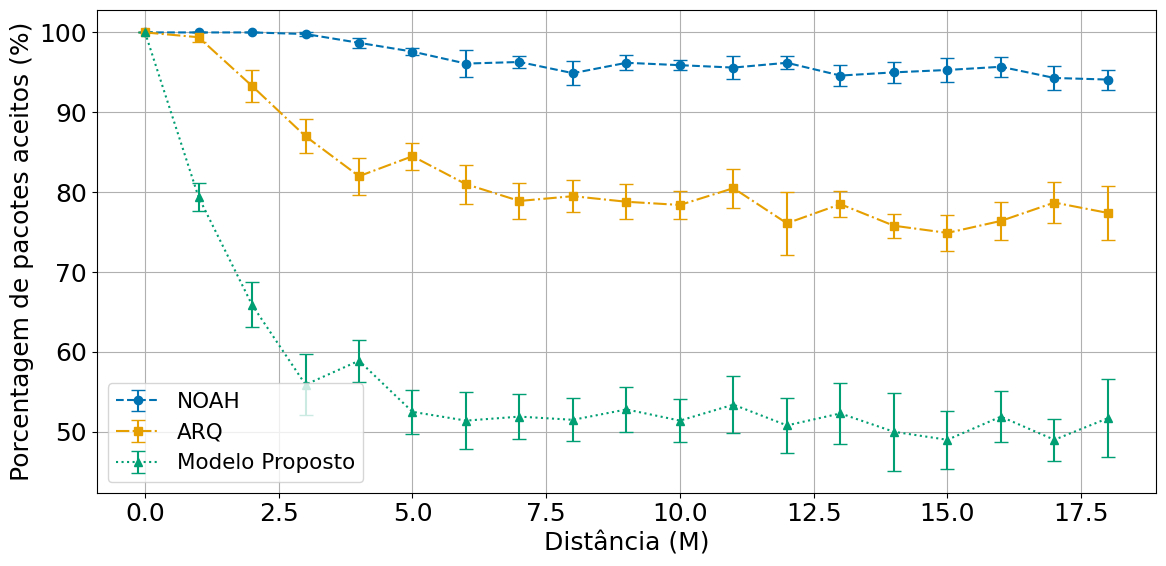

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Ler o CSV
# ==========================================
df_antigo = pd.read_csv("Comparacao_Final.csv")

# ==========================================
# Extrair colunas
# ==========================================

df = df_antigo[df_antigo["Distância (m)"] <= 19]

df.to_csv("Comparacao_Final_ate8m.csv", index=False)

dist = df["Distância (m)"]

media_A = df["Média A"]
ic95_A = df["IC95 A"]

media_B = df["Média B"]
ic95_B = df["IC95 B"]

media_C = df["Média C"]
ic95_C = df["IC95 C"]

#valores_D = df["Execução D"]

# ==========================================
# Plot
# ==========================================



plt.figure(figsize=(12, 6))
plt.rcParams['font.size'] = 18

plt.errorbar(dist, media_A, yerr=ic95_A,
             color="#0072B2",
             marker='o', linestyle='--', capsize=5, label='NOAH')

plt.errorbar(dist, media_B, yerr=ic95_B,
             color="#E69F00",
             marker='s',linestyle = '-.', capsize=5, label='ARQ')

plt.errorbar(dist, media_C, yerr=ic95_C,
             color="#009E73",
             marker='^',linestyle = ":", capsize=5, label='Modelo Proposto')

"""plt.plot(dist, valores_D,
         color="#D55E00",
         marker='x', label='Modelo Original')"""


color='0.3'   # cinza escuro
color='0.5'   # cinza médio
color='0.7'   # cinza claro
#plt.ylim(31,105)
plt.xlabel("Distância (M)")
plt.ylabel("Porcentagem de pacotes aceitos (%)")
plt.grid(True)
plt.legend(fontsize = 15.5)



#plt.xticks(dist)

plt.tight_layout()
plt.show()


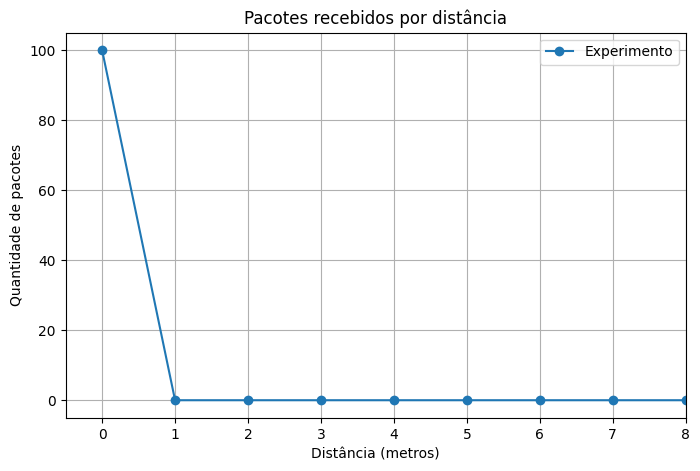

In [ ]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict


# ==================================================
# FUNÇÃO BASE (mantida igual)
# ==================================================
def contar_fim_do_pacote_por_distancia(caminho_arquivo):
    contagem = defaultdict(int)
    distancia_atual = None

    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        for linha in f:
            linha = linha.strip()

            m_dist = re.match(r'Distance between TX and RX is (\d+) meters', linha)
            if m_dist:
                distancia_atual = int(m_dist.group(1))
                continue

            if linha == "-------FIM DO PACOTE-------":
                if distancia_atual is not None:
                    contagem[distancia_atual] += 1

    return contagem


# ==================================================
# ESCOLHA DO ARQUIVO
# ==================================================
arquivo = "resultsD1.txt"  # <-- coloque aqui o arquivo desejado


# ==================================================
# PROCESSAMENTO
# ==================================================
contagem = contar_fim_do_pacote_por_distancia(arquivo)

distancias = list(range(0, 19))
valores = [contagem.get(d, 0) for d in distancias]



# ==================================================
# PLOT
# ==================================================
plt.figure(figsize=(8, 5))

plt.xlim(-0.5, 8)


plt.plot(distancias, valores, marker='o', label='Experimento')

plt.xlabel("Distância (metros)")
plt.ylabel("Quantidade de pacotes")
plt.title("Pacotes recebidos por distância")
plt.grid(True)
plt.legend()

plt.show()
